In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The following cell is just the preparation for the analysis loading in the libraries and file and the first 5 rows of the file

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load your file (Ensure you upload your CSV to the Colab 'Files' folder first)
df = pd.read_csv('2026 Automotive Trends_ Gas vs. Electric Vehicle Study  (Responses).csv')

# Show the first 5 rows to verify the manual naming you did
print("Dataset successfully loaded!")
df.head()

Dataset successfully loaded!


,gender,major,age_range,academic_year,is_driver,current_vehicle,daily_dist_km,long_trip_freq,parking_type,min_range_req,est_gas_maint,est_ev_maint,primary_barrier,infra_trust,future_intent
0,Male,Computer Science,18 - 24,2nd Year (Sophomore),yes,Gas,100.0,Weekly,On Street/Public Parking,500,25000,10000,Battery Life Concerns,6,Yes
1,Male,Business,18 - 24,2nd Year (Sophomore),yes,Gas,100.0,Monthly,Private Garage,300,20000,10000,Charging Access,5,Undecided
2,Male,Engineering,18 - 24,2nd Year (Sophomore),yes,Gas,40.0,1-2 times a year,On Street/Public Parking,300,100000,25000,I don't want an EV,8,No
3,Male,Arts,18 - 24,1st Year (Freshman),yes,Gas,50.0,1-2 times a year,Private Garage,300,30000,250000,Charging Access,7,No
4,Male,Dentistry,18 - 24,1st Year (Freshman),yes,Gas,25.0,Every 3 months,Private Garage,300,35000,20000,Charging Access,3,Yes


here we are going to be cleaning the dataset of any accidental inputs ("km" or "$")

In [5]:
# List of columns that MUST be numbers for math to work
numeric_cols = ['daily_dist_km', 'min_range_req', 'est_gas_maint', 'est_ev_maint', 'infra_trust']

for col in numeric_cols:
    # Convert to numeric, turning errors like "I don't know" into NaN (Empty)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values with the Median to keep the analysis stable
df = df.fillna(df.median(numeric_only=True))

print("Data scrubbing complete. Numeric columns are ready for calculation.")

Data scrubbing complete. Numeric columns are ready for calculation.


 Here is the core statistic requirements of our project the mean, median and mode for each varibale this shows the average user using our dataset

In [26]:
# Calculating central tendencies
stats = df[numeric_cols].agg(['mean', 'median'])
modes = df[numeric_cols].mode().iloc[0]

# Combine into a clear table using pd.concat as .append() is deprecated
final_stats = pd.concat([stats, pd.DataFrame([modes], index=['mode'])]).round(2)
print("--- CENTRAL TENDENCY SUMMARY ---")
print(final_stats)

--- CENTRAL TENDENCY SUMMARY ---
        daily_dist_km  min_range_req  est_gas_maint  est_ev_maint  infra_trust
mean            60.62         362.24        30014.8      26226.43         5.35
median          50.00         300.00        20000.0      10000.00         5.00
mode           100.00         300.00        20000.0       5000.00         7.00


The following is a line graph for the daily usage vs the required range to analyse how the "percieved" range of an ev is different from the daily usage as a scale

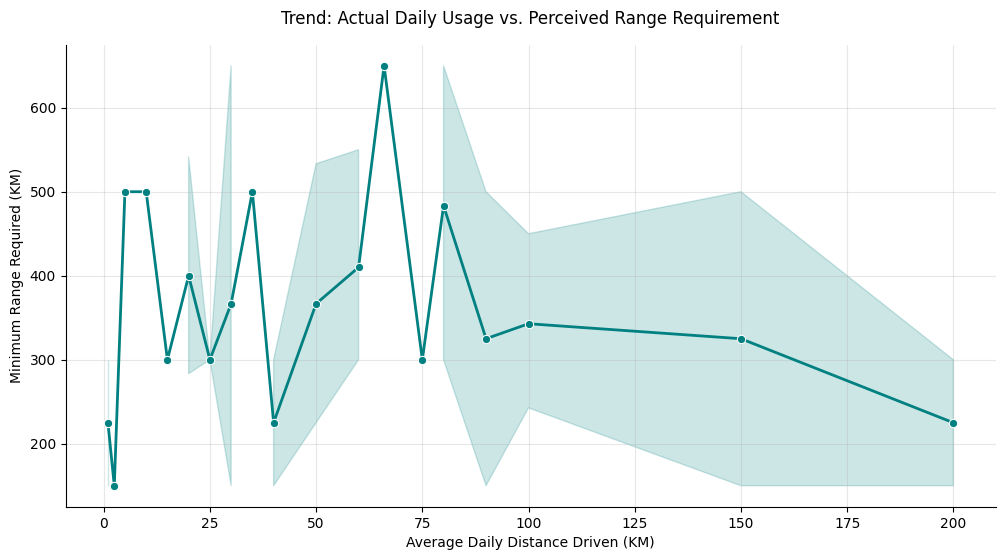

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='daily_dist_km', y='min_range_req', marker='o', color='teal', linewidth=2)

plt.title('Trend: Actual Daily Usage vs. Perceived Range Requirement', pad=15)
plt.xlabel('Average Daily Distance Driven (KM)')
plt.ylabel('Minimum Range Required (KM)')
plt.grid(True, alpha=0.3)
sns.despine()
plt.show()

Here we use a bar graph to group genders and see how different each gender needs for a adoptation of an Ev

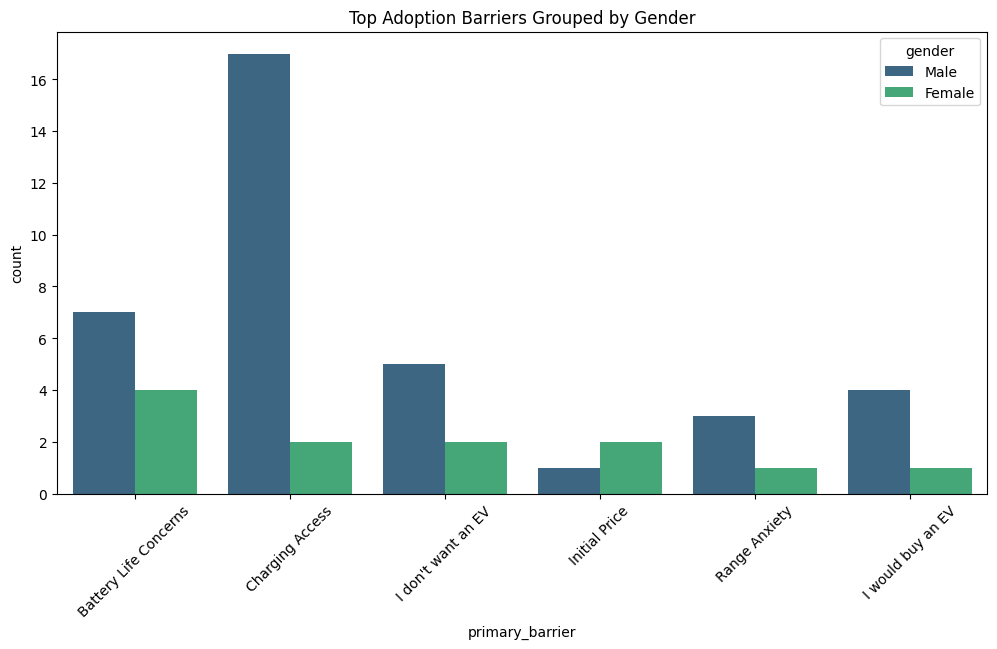

In [10]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='primary_barrier', hue='gender', palette='viridis')
plt.title('Top Adoption Barriers Grouped by Gender')
plt.xticks(rotation=45)
plt.show()

shows the relation of majors and the primary barrier to see whether major effects the thinking process of choosing an ev

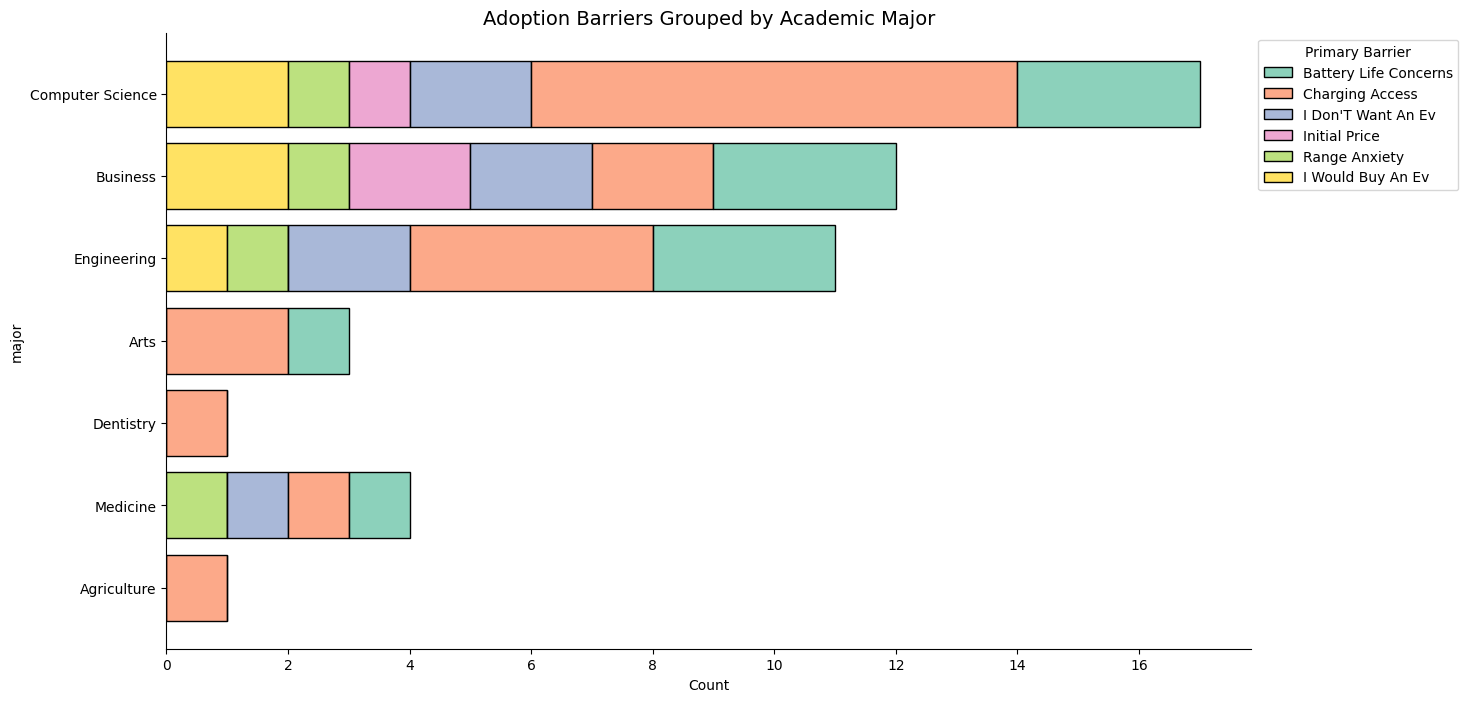

In [22]:
plt.figure(figsize=(14, 8))
ax = sns.histplot(data=df, y='major', hue='primary_barrier', multiple='stack', shrink=0.8, palette='Set2')

plt.title('Adoption Barriers Grouped by Academic Major', fontsize=14)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Primary Barrier')
sns.despine()
plt.show()

Here is a heat map the shows the correlation matric of each of our survey questions

How to read it:  

1.0: Perfect positive relationship.
-1.0: Perfect opposite relationship.
0.0: No relationship at all.

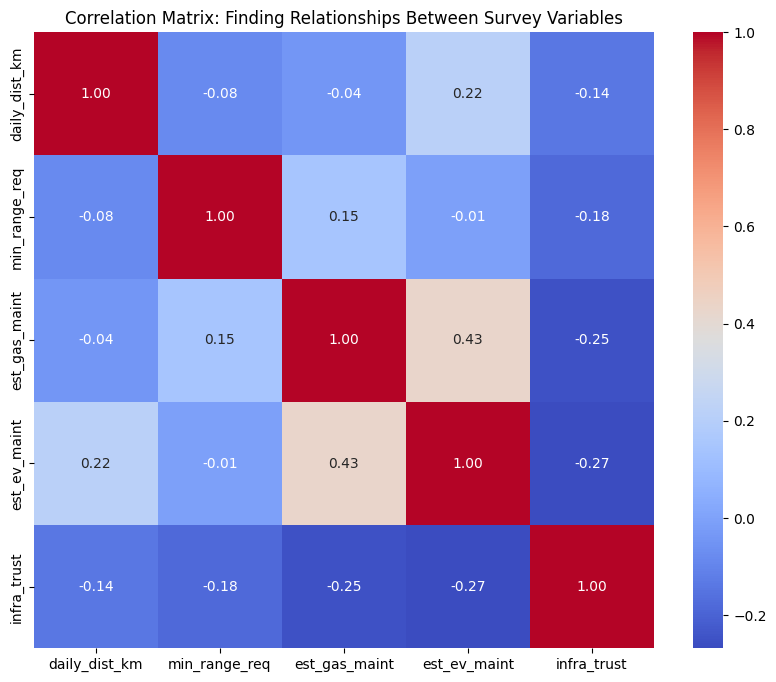

In [11]:
plt.figure(figsize=(10, 8))
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Finding Relationships Between Survey Variables')
plt.show()

For all our

/tmp/ipykernel_1026/2008484952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=maint_comp, x='Powertrain', y='Cost', palette='Set1')


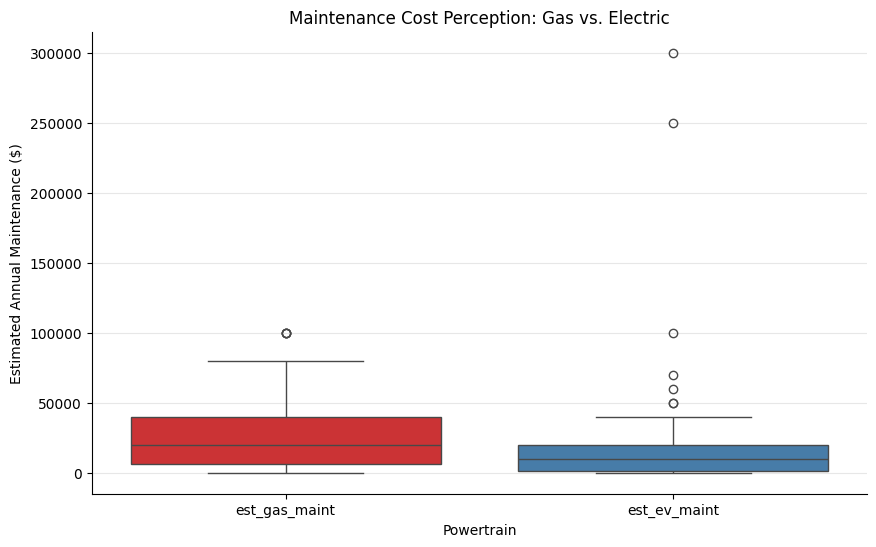

In [21]:
# Reshaping data for comparison
maint_comp = df[['est_gas_maint', 'est_ev_maint']].melt(var_name='Powertrain', value_name='Cost')

plt.figure(figsize=(10, 6))
sns.boxplot(data=maint_comp, x='Powertrain', y='Cost', palette='Set1')

plt.title('Maintenance Cost Perception: Gas vs. Electric')
plt.ylabel('Estimated Annual Maintenance ($)')
plt.grid(axis='y', alpha=0.3)
sns.despine()
plt.show()

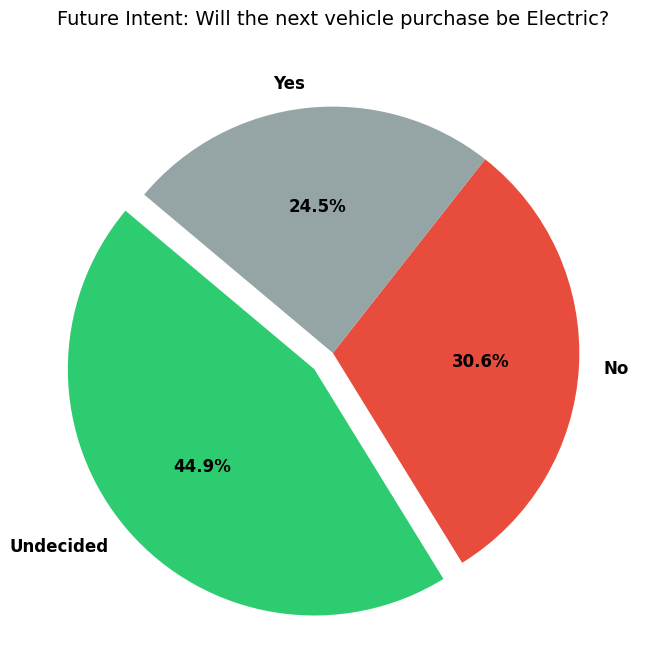

In [27]:
# Cell 8: Market Sentiment Analysis - Next Vehicle Intent
plt.figure(figsize=(8, 8))

# 1. Clean the data to standardize text and avoid "No" vs "no"
df['future_intent'] = df['future_intent'].astype(str).str.strip().str.title()

# 2. Count responses and define colors for sentiment
intent_counts = df['future_intent'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#95a5a6'] # Green=Yes, Red=No, Gray=Undecided

# 3. Create the Pie Chart
intent_counts.plot.pie(
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    explode=(0.1, 0, 0), # Pulls "Yes" segment out slightly
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Future Intent: Will the next vehicle purchase be Electric?', fontsize=14, pad=15)
plt.ylabel('') # Hides the default 'future_intent' label on the side
plt.show()

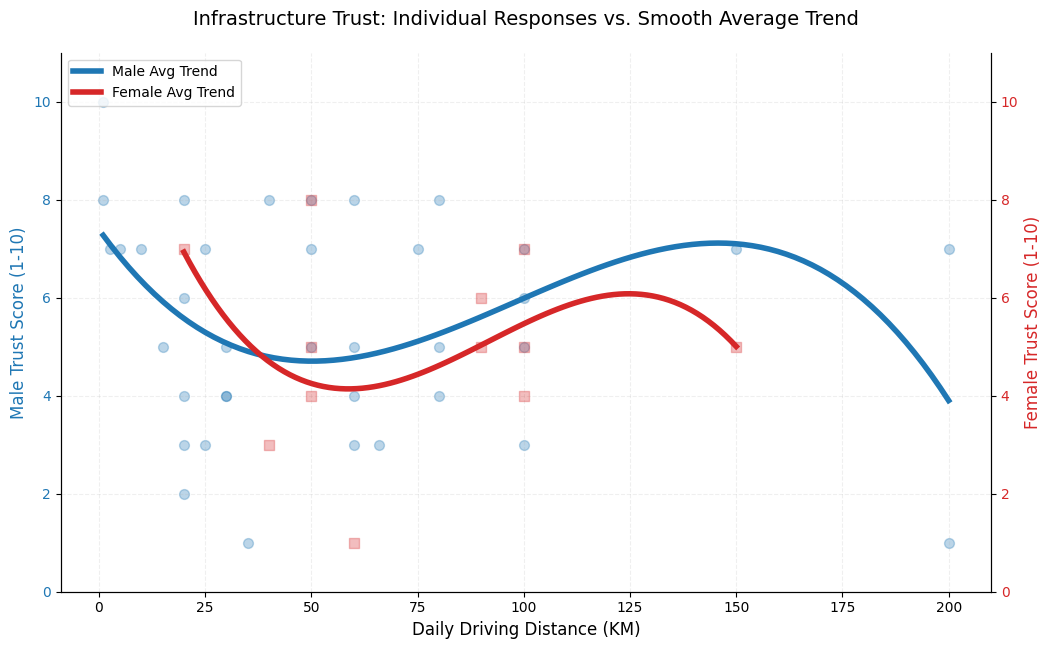

In [30]:
import numpy as np

# 1. Prepare data - Filtering and Sorting
male_data = df[df['gender'] == 'Male'].sort_values('daily_dist_km')
female_data = df[df['gender'] == 'Female'].sort_values('daily_dist_km')

# 2. Initialize the plot
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- MALE DATA (Left Y-Axis) ---
color_male = 'tab:blue'
# Plot each individual response as a transparent dot
ax1.scatter(male_data['daily_dist_km'], male_data['infra_trust'],
            color=color_male, alpha=0.3, s=50, label='Male Responses')

# Calculate the smooth average line (Polynomial Fit - Degree 3)
z_m = np.polyfit(male_data['daily_dist_km'], male_data['infra_trust'], 3)
p_m = np.poly1d(z_m)
x_new_m = np.linspace(male_data['daily_dist_km'].min(), male_data['daily_dist_km'].max(), 100)
line1, = ax1.plot(x_new_m, p_m(x_new_m), color=color_male, linewidth=4, label='Male Avg Trend')

ax1.set_xlabel('Daily Driving Distance (KM)', fontsize=12)
ax1.set_ylabel('Male Trust Score (1-10)', color=color_male, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_male)
ax1.set_ylim(0, 11) # Fixed scale for clear comparison

# --- FEMALE DATA (Right Y-Axis) ---
ax2 = ax1.twinx()
color_female = 'tab:red'
# Plot each individual response as a transparent dot
ax2.scatter(female_data['daily_dist_km'], female_data['infra_trust'],
            color=color_female, alpha=0.3, s=50, marker='s', label='Female Responses')

# Calculate the smooth average line for females
z_f = np.polyfit(female_data['daily_dist_km'], female_data['infra_trust'], 3)
p_f = np.poly1d(z_f)
x_new_f = np.linspace(female_data['daily_dist_km'].min(), female_data['daily_dist_km'].max(), 100)
line2, = ax2.plot(x_new_f, p_f(x_new_f), color=color_female, linewidth=4, label='Female Avg Trend')

ax2.set_ylabel('Female Trust Score (1-10)', color=color_female, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_female)
ax2.set_ylim(0, 11) # Fixed scale for clear comparison

# 3. Legend and Styling
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)

plt.title('Infrastructure Trust: Individual Responses vs. Smooth Average Trend', fontsize=14, pad=20)
ax1.grid(True, linestyle='--', alpha=0.2)
sns.despine(right=False)

plt.show()